# Exploratory Data Analysis — Customer Churn

### Sections
1. Setup & Data Loading
2. Dataset Overview
3. Target Variable Analysis
4. Numeric Feature Analysis
5. Categorical Feature Analysis
6. Correlation & Multicollinearity
7. Bivariate Analysis (Features vs Churn)
8. Key Insights & Next Steps

---
## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
import os
import sys

warnings.filterwarnings('ignore')
sys.path.append(os.path.abspath('..'))

# Plot style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)

CHURN_COLORS = {'No': '#4C9BE8', 'Yes': '#E8684C'}
print('Libraries loaded ✅')

Libraries loaded ✅


In [2]:
DATA_PATH = '../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv'

df_raw = pd.read_csv(DATA_PATH)
df = df_raw.copy()

print(f'Shape: {df.shape}')
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


---
## 2. Dataset Overview

In [3]:
print('=== Shape ===')
print(f'Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}')

print('\n=== Data Types ===')
print(df.dtypes.value_counts())

=== Shape ===
Rows: 7,043  |  Columns: 21

=== Data Types ===
object     18
int64       2
float64     1
dtype: int64


In [4]:
# Fix known issue: TotalCharges has spaces instead of NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print('=== Missing Values ===')
missing = df.isnull().sum()
missing = missing[missing > 0]
if missing.empty:
    print('No missing values (after TotalCharges fix).')
else:
    print(missing.to_frame('count').assign(pct=lambda x: (x['count']/len(df)*100).round(2)))

=== Missing Values ===
              count   pct
TotalCharges     11  0.16


In [5]:
print('=== Duplicates ===')
print(f'Duplicate rows: {df.duplicated().sum()}')

print('\n=== Summary Statistics (Numeric) ===')
df.describe().T.style.background_gradient(cmap='Blues', axis=1)

=== Duplicates ===
Duplicate rows: 0

=== Summary Statistics (Numeric) ===


,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.000000,0.162147,0.368612,0.000000,0.000000,0.000000,0.000000,1.000000
tenure,7043.000000,32.371149,24.559481,0.000000,9.000000,29.000000,55.000000,72.000000
MonthlyCharges,7043.000000,64.761692,30.090047,18.250000,35.500000,70.350000,89.850000,118.750000
TotalCharges,7032.000000,2283.300441,2266.771362,18.800000,401.450000,1397.475000,3794.737500,8684.800000


In [6]:
print('=== Summary Statistics (Categorical) ===')
df.describe(include='object').T

=== Summary Statistics (Categorical) ===


,count,unique,top,freq
customerID,7043,7043,7590-VHVEG,1
gender,7043,2,Male,3555
Partner,7043,2,No,3641
Dependents,7043,2,No,4933
PhoneService,7043,2,Yes,6361
MultipleLines,7043,3,No,3390
InternetService,7043,3,Fiber optic,3096
OnlineSecurity,7043,3,No,3498
OnlineBackup,7043,3,No,3088
DeviceProtection,7043,3,No,3095


---
## 3. Target Variable Analysis

=== Churn Distribution ===
     Count  Percentage
No    5174       73.46
Yes   1869       26.54


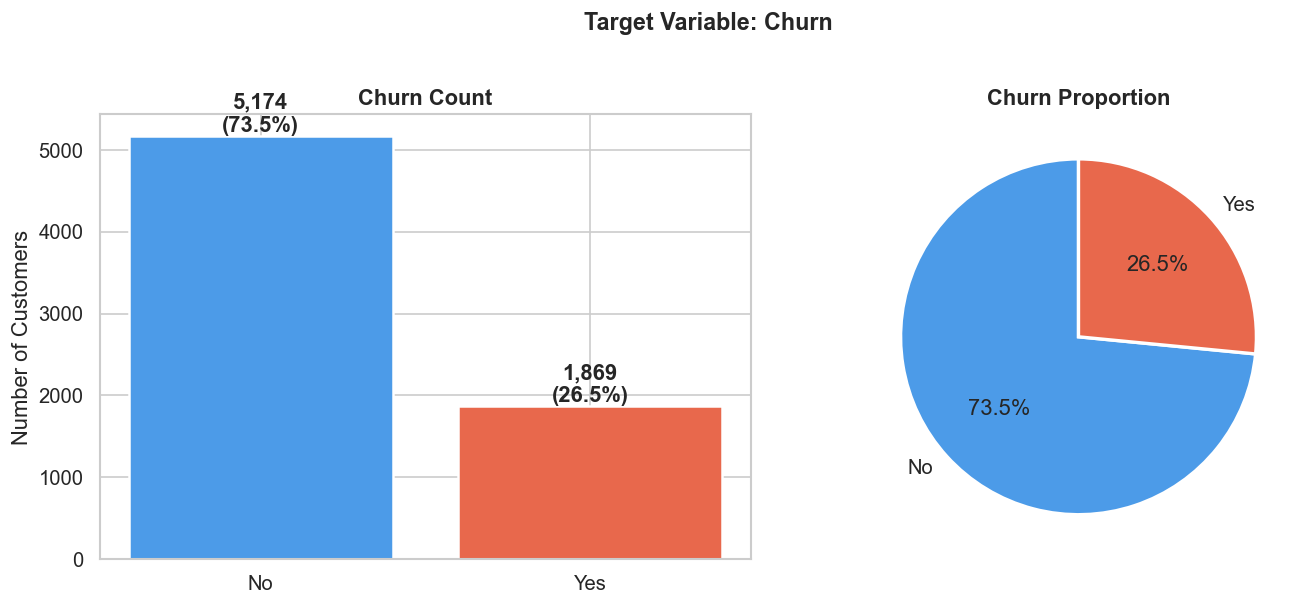

✅ Classes are reasonably balanced.


In [7]:
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print('=== Churn Distribution ===')
print(pd.DataFrame({'Count': churn_counts, 'Percentage': churn_pct.round(2)}))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
axes[0].bar(churn_counts.index, churn_counts.values,
            color=[CHURN_COLORS[k] for k in churn_counts.index], edgecolor='white', linewidth=1.5)
for i, (k, v) in enumerate(churn_counts.items()):
    axes[0].text(i, v + 50, f'{v:,}\n({churn_pct[k]:.1f}%)', ha='center', fontweight='bold')
axes[0].set_title('Churn Count', fontweight='bold')
axes[0].set_ylabel('Number of Customers')
axes[0].set_xlabel('')

# Pie chart
axes[1].pie(churn_counts.values, labels=churn_counts.index,
            colors=[CHURN_COLORS[k] for k in churn_counts.index],
            autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Churn Proportion', fontweight='bold')

plt.suptitle('Target Variable: Churn', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('\n⚠️  Class Imbalance Detected!' if churn_pct.min() < 25 else '✅ Classes are reasonably balanced.')

---
## 4. Numeric Feature Analysis

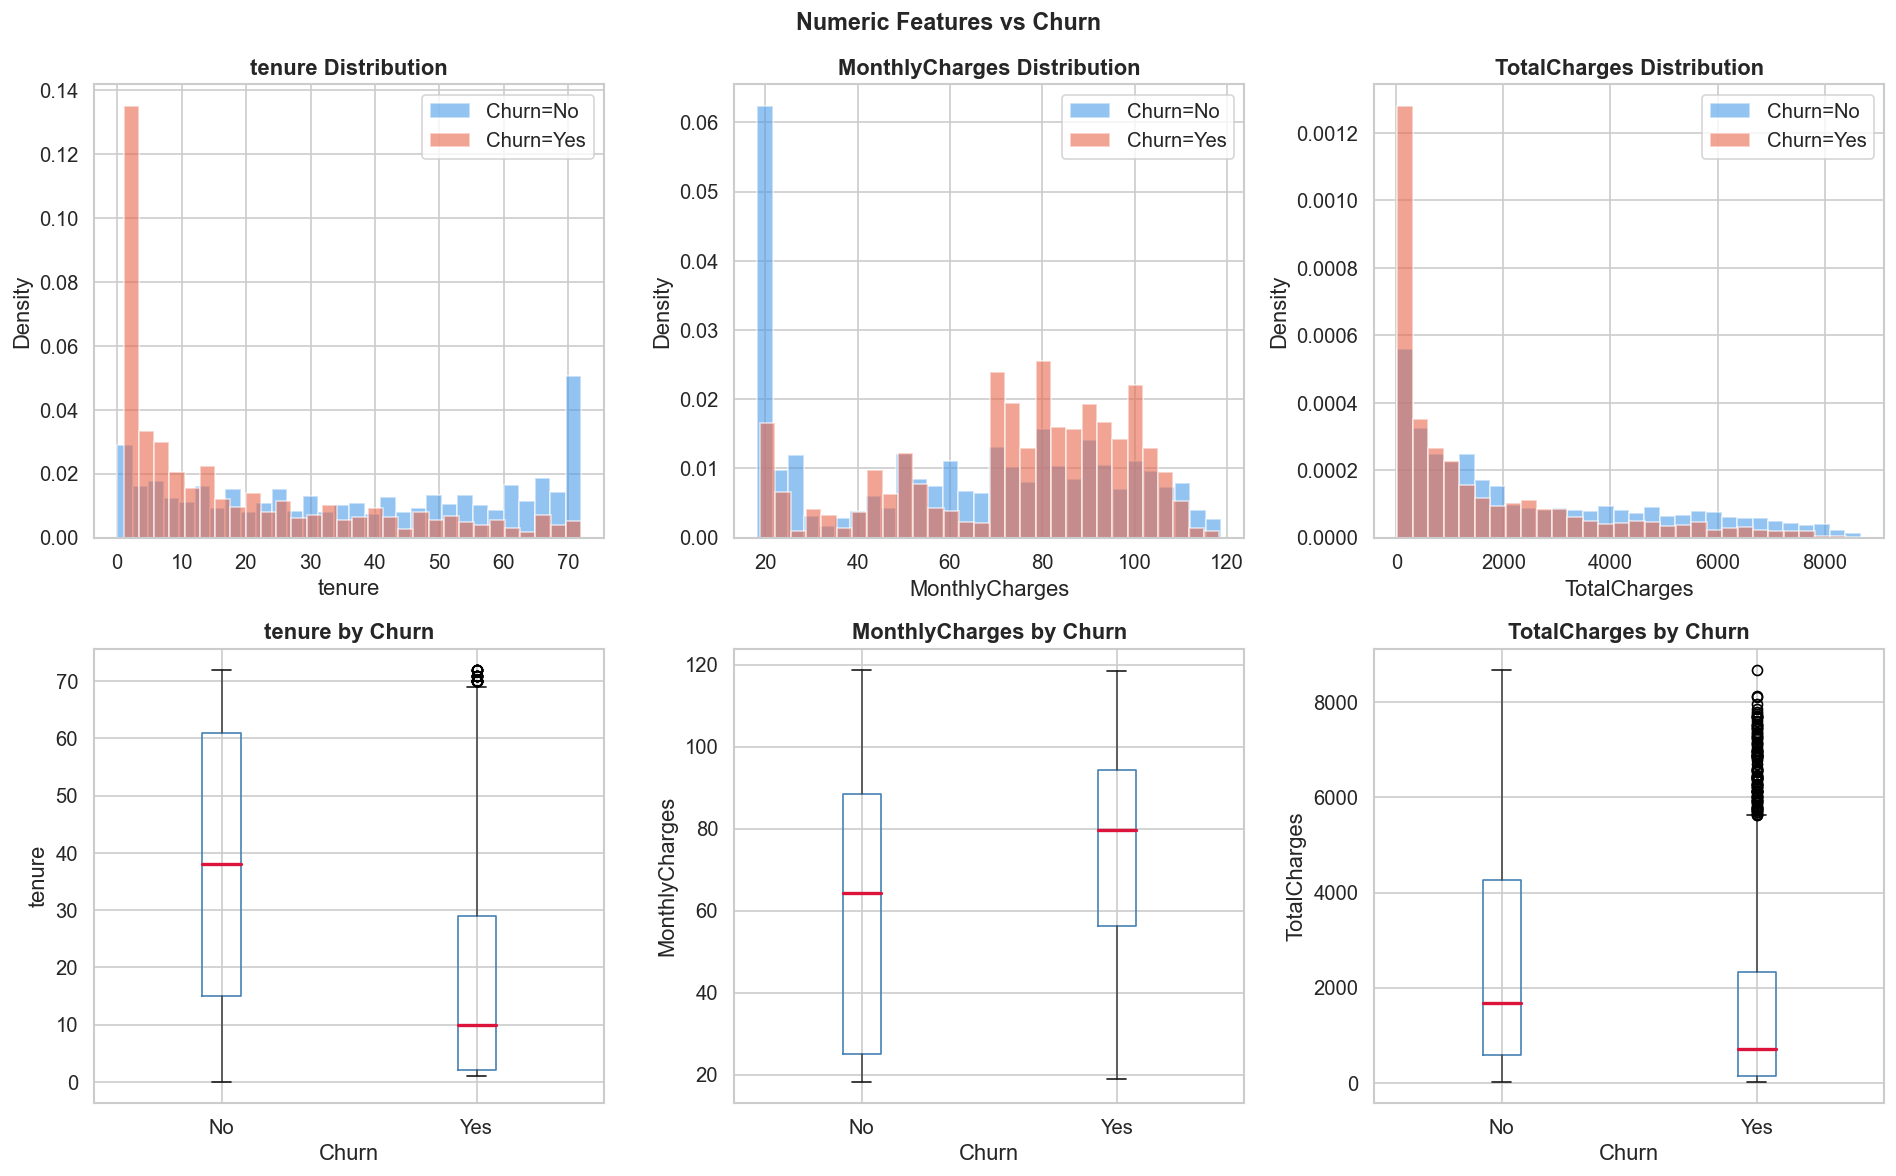

In [8]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for i, col in enumerate(num_cols):
    # Distribution
    ax = axes[0, i]
    for churn_val, color in CHURN_COLORS.items():
        subset = df[df['Churn'] == churn_val][col].dropna()
        ax.hist(subset, bins=30, alpha=0.6, color=color, label=f'Churn={churn_val}', density=True)
    ax.set_title(f'{col} Distribution', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    ax.legend()

    # Box plot
    ax2 = axes[1, i]
    df.boxplot(column=col, by='Churn', ax=ax2,
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='crimson', linewidth=2))
    ax2.set_title(f'{col} by Churn', fontweight='bold')
    ax2.set_xlabel('Churn')
    ax2.set_ylabel(col)

plt.suptitle('Numeric Features vs Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

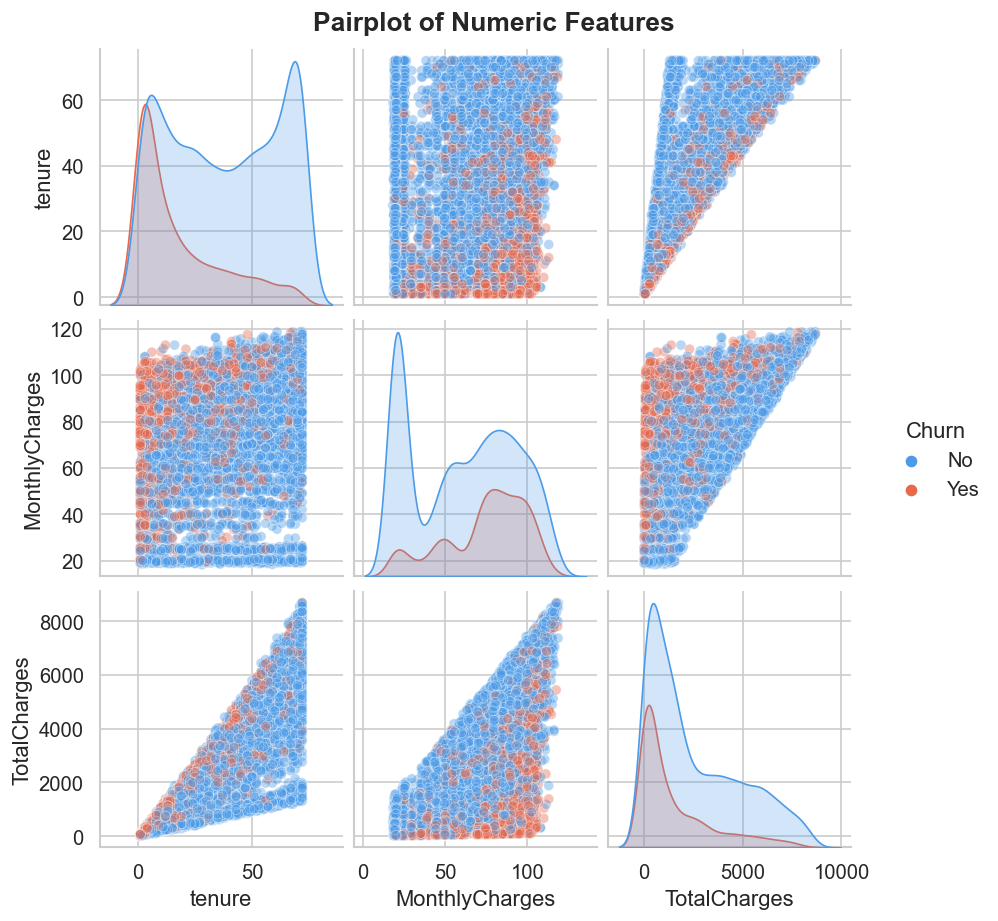

In [9]:
# Pairplot for numeric features
pair_df = df[num_cols + ['Churn']].dropna()
g = sns.pairplot(pair_df, hue='Churn', palette=CHURN_COLORS, plot_kws={'alpha': 0.4}, diag_kind='kde')
g.fig.suptitle('Pairplot of Numeric Features', y=1.02, fontweight='bold')
plt.show()

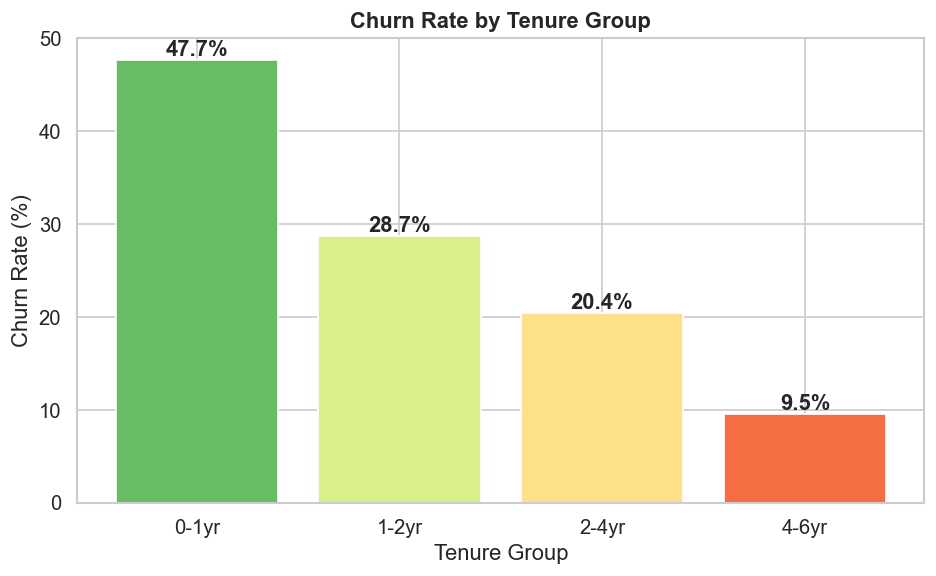

In [10]:
# Tenure buckets — useful for storytelling
df['tenure_group'] = pd.cut(df['tenure'], bins=[0, 12, 24, 48, 72],
                             labels=['0-1yr', '1-2yr', '2-4yr', '4-6yr'])

tenure_churn = df.groupby('tenure_group')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
).reset_index()
tenure_churn.columns = ['tenure_group', 'churn_rate']

plt.figure(figsize=(8, 5))
bars = plt.bar(tenure_churn['tenure_group'].astype(str), tenure_churn['churn_rate'],
               color=sns.color_palette('RdYlGn_r', len(tenure_churn)), edgecolor='white')
for bar, val in zip(bars, tenure_churn['churn_rate']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontweight='bold')
plt.title('Churn Rate by Tenure Group', fontweight='bold')
plt.xlabel('Tenure Group')
plt.ylabel('Churn Rate (%)')
plt.tight_layout()
plt.show()

---
## 5. Categorical Feature Analysis

In [11]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols = [c for c in cat_cols if c not in ['customerID', 'Churn']]
print(f'Categorical features ({len(cat_cols)}): {cat_cols}')

Categorical features (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


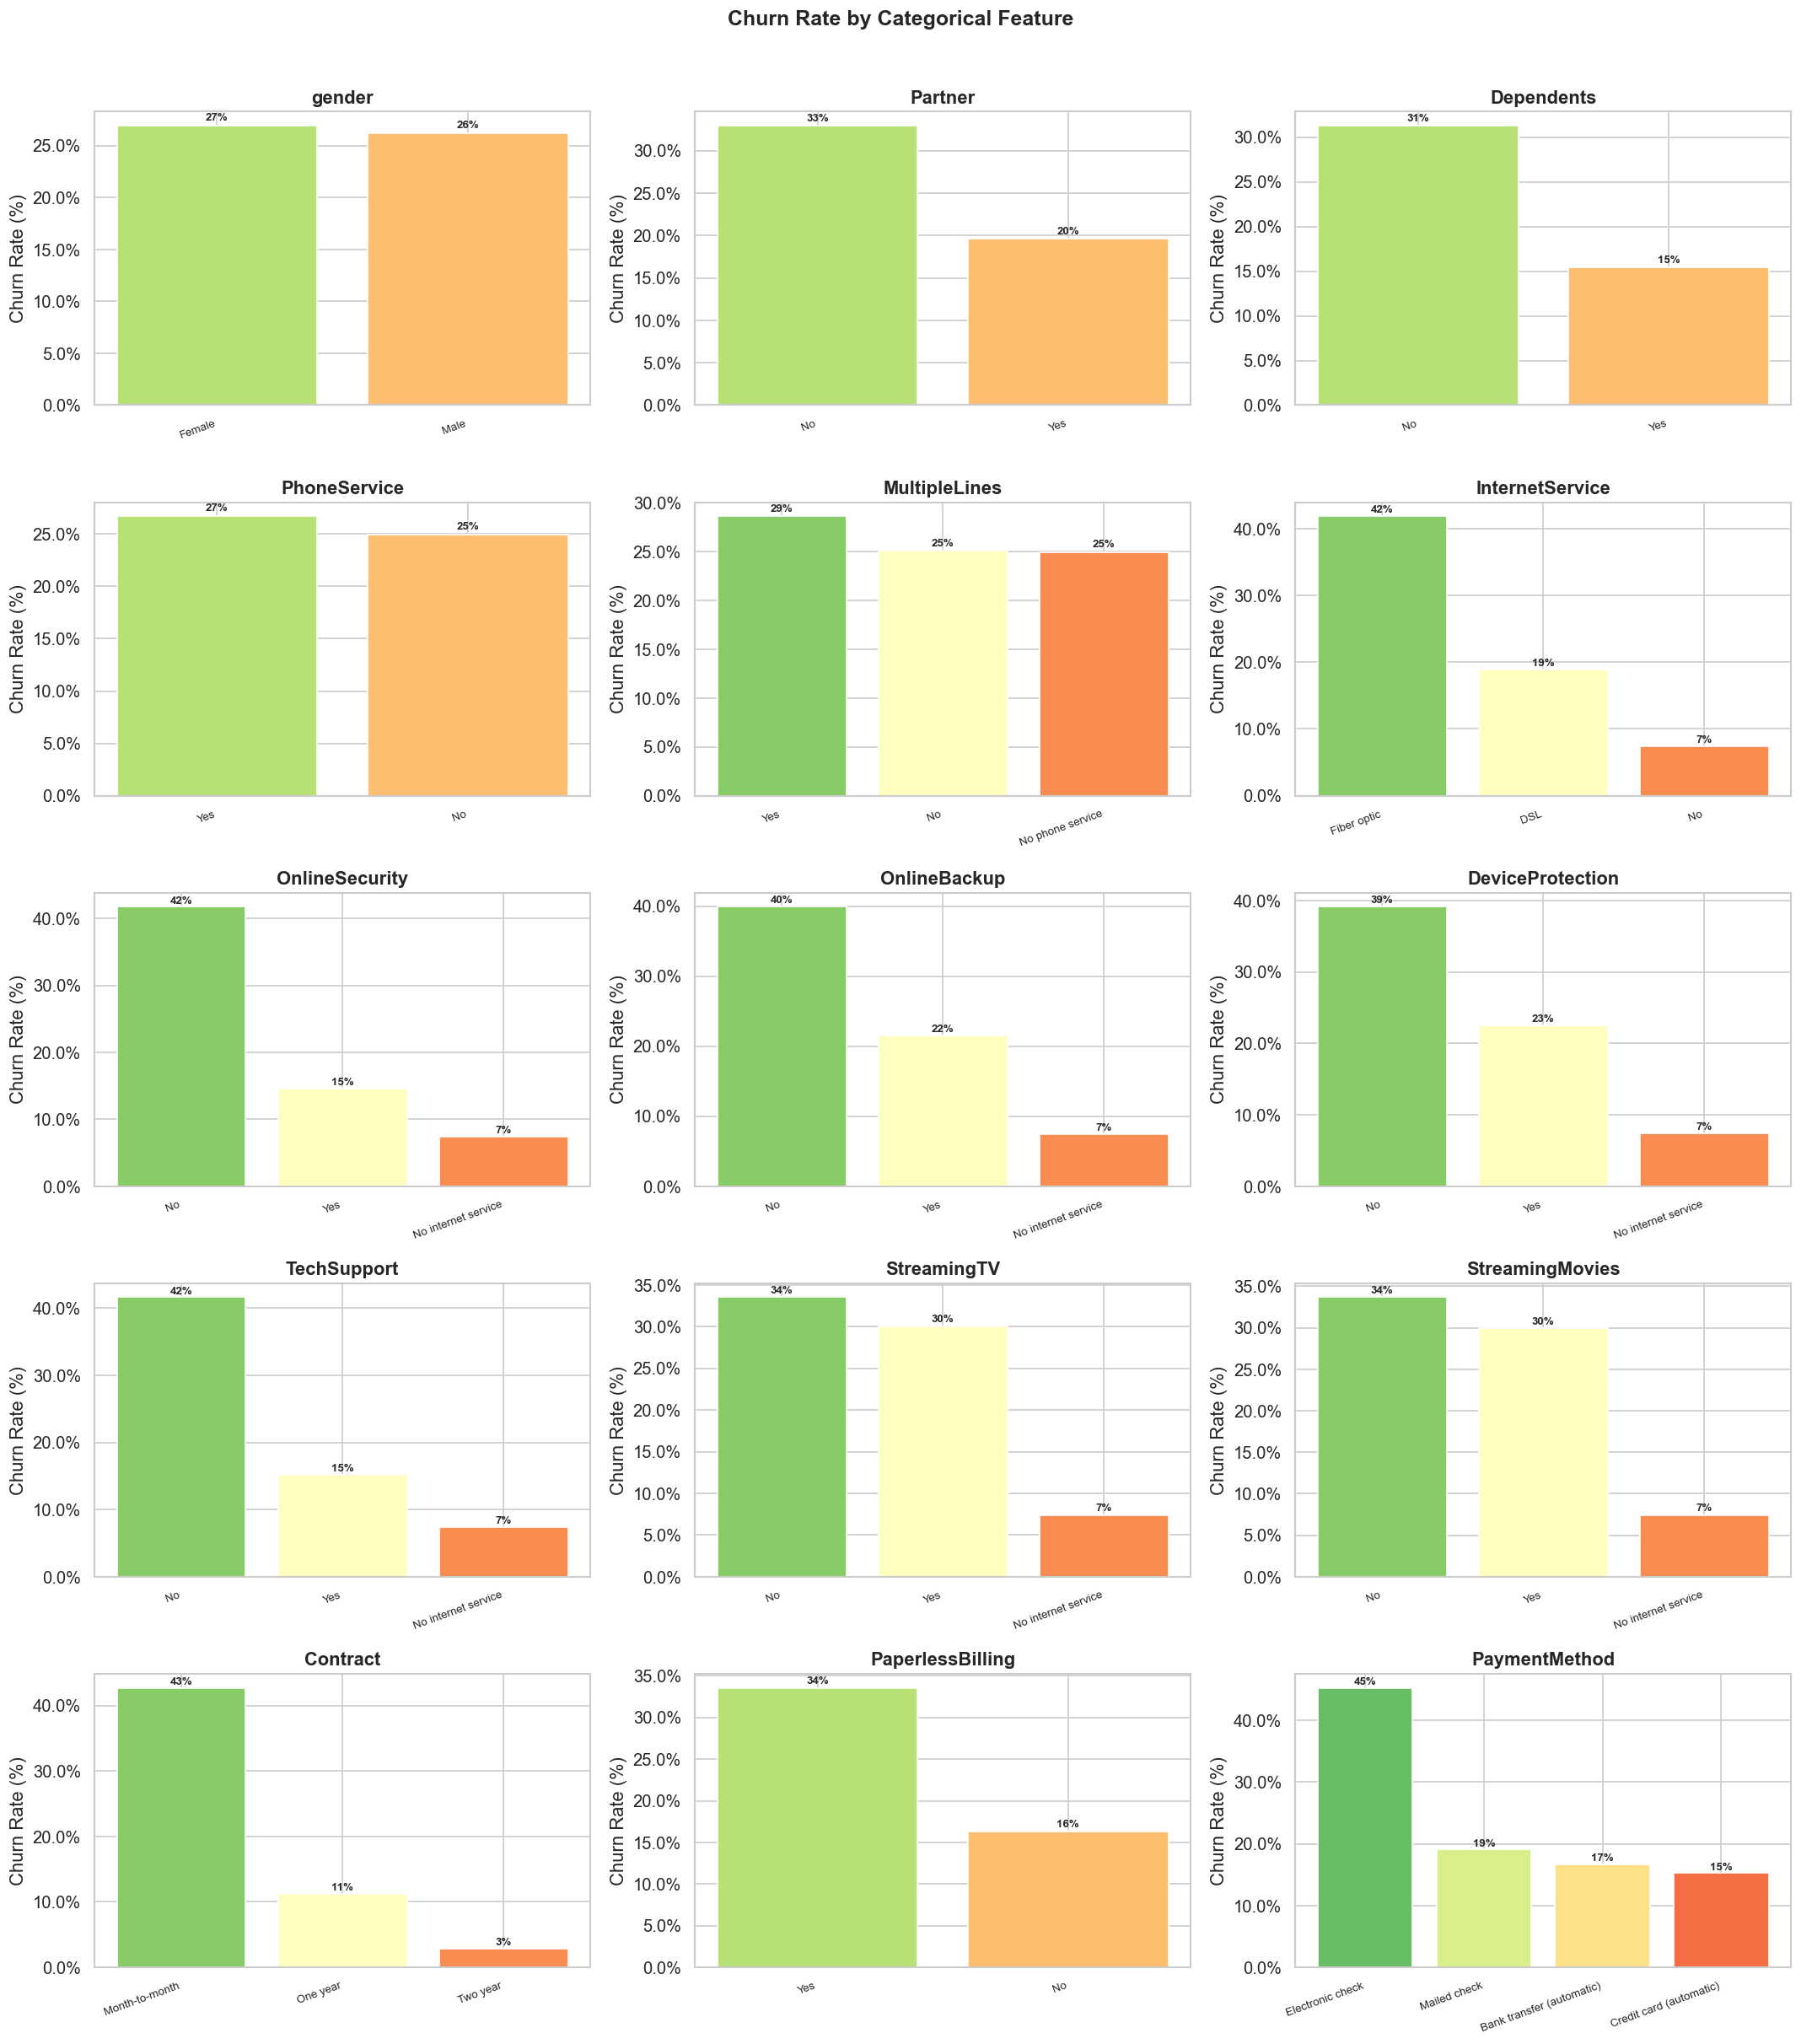

In [12]:
# Churn rate by each categorical feature
def plot_churn_rate_by_cat(df, col, ax):
    order = df.groupby(col)['Churn'].apply(lambda x: (x=='Yes').mean()).sort_values(ascending=False).index
    churn_rates = df.groupby(col)['Churn'].apply(lambda x: (x=='Yes').mean() * 100).reindex(order)
    counts = df[col].value_counts().reindex(order)

    colors = sns.color_palette('RdYlGn_r', len(order))
    bars = ax.bar(range(len(order)), churn_rates.values, color=colors, edgecolor='white')

    for i, (bar, val, cnt) in enumerate(zip(bars, churn_rates.values, counts.values)):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.0f}%', ha='center', fontsize=8, fontweight='bold')

    ax.set_title(col, fontweight='bold')
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(order, rotation=20, ha='right', fontsize=8)
    ax.set_ylabel('Churn Rate (%)')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())


n_cols_plot = 3
n_rows_plot = (len(cat_cols) + n_cols_plot - 1) // n_cols_plot
fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(18, n_rows_plot * 4))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    plot_churn_rate_by_cat(df, col, axes[i])

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Churn Rate by Categorical Feature', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

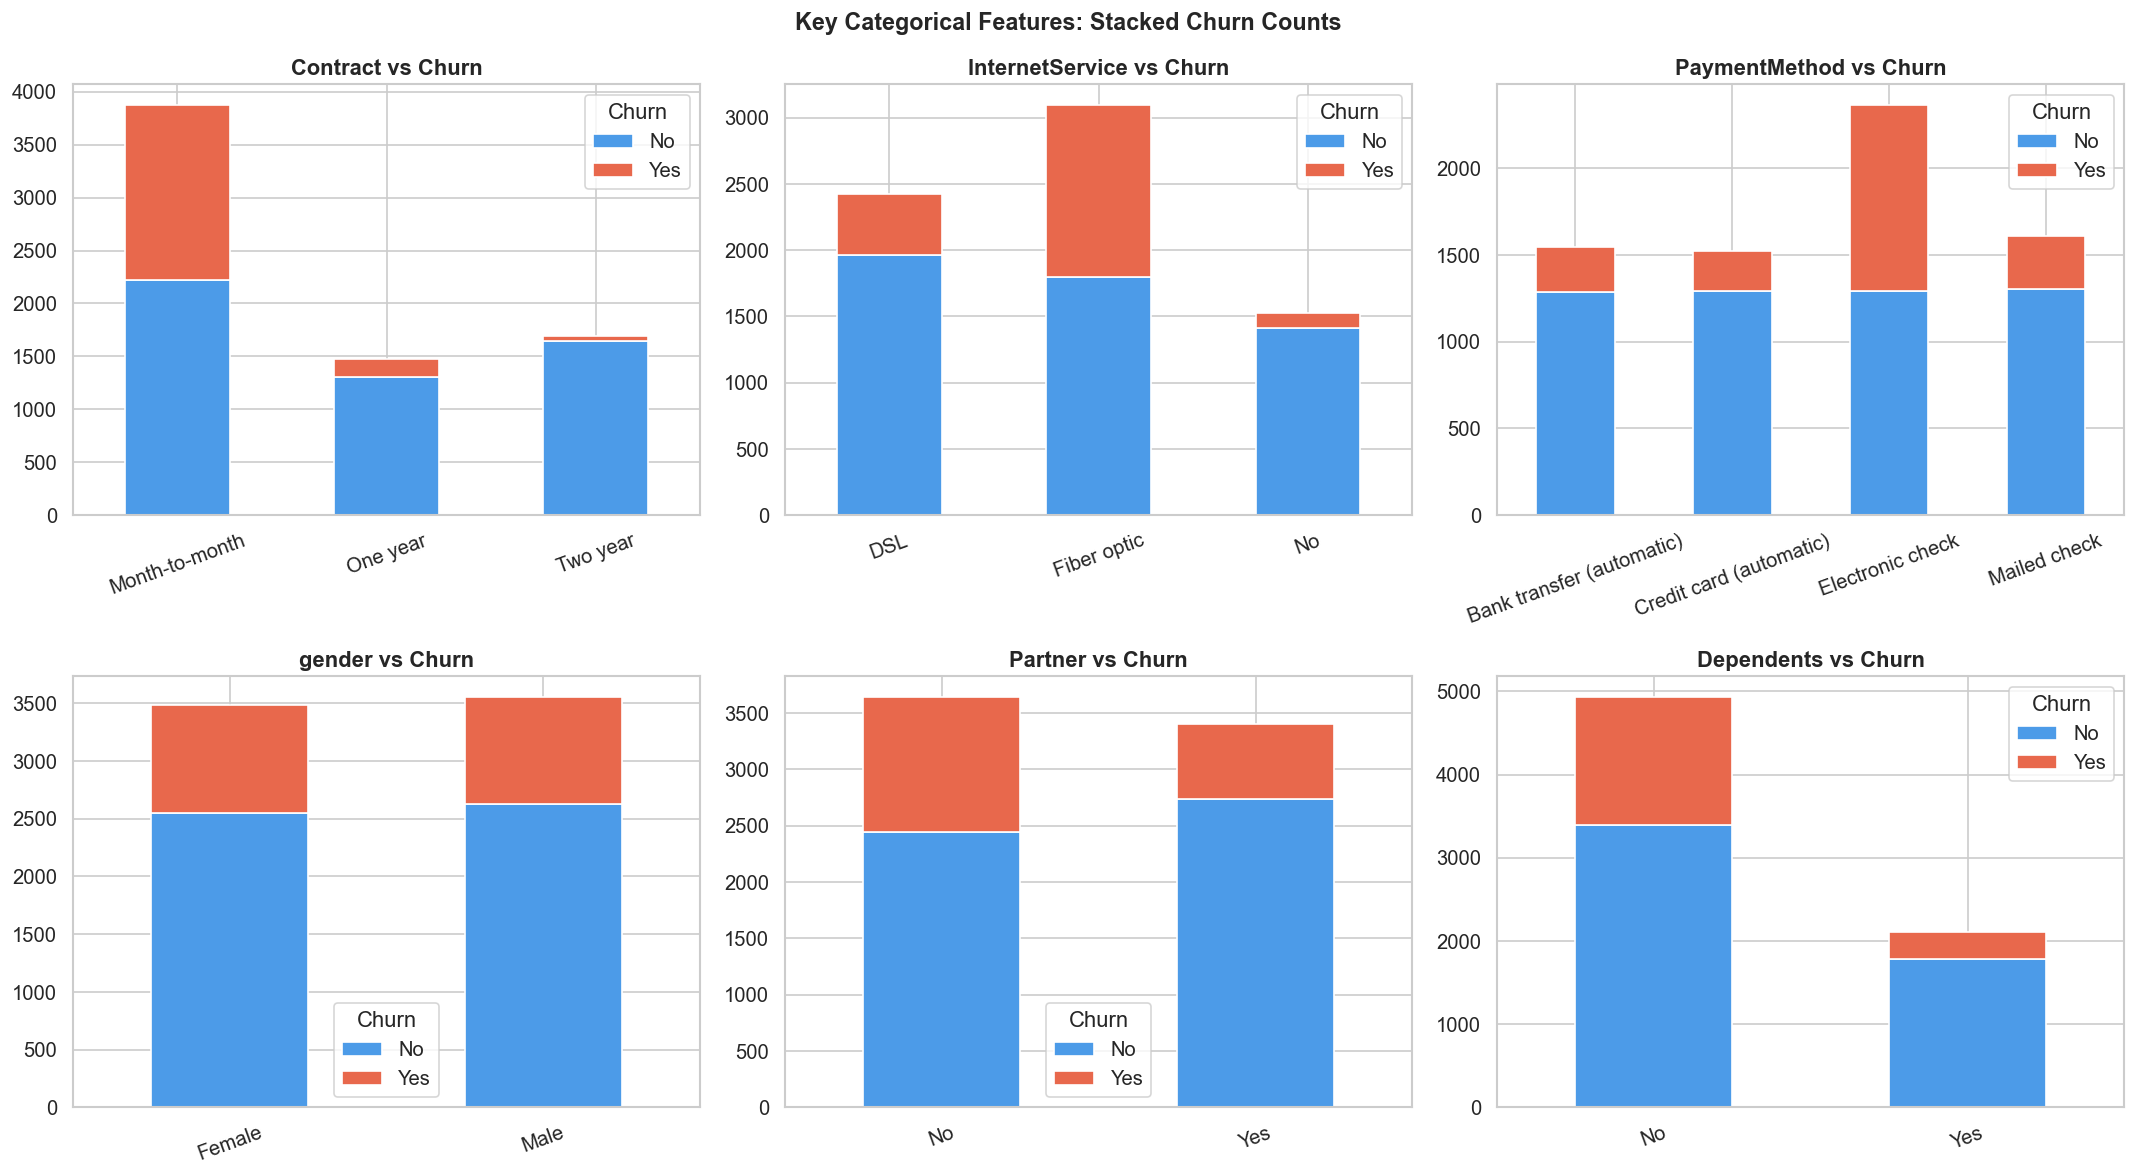

In [13]:
# Stacked bar — absolute counts with churn overlay
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

key_cats = ['Contract', 'InternetService', 'PaymentMethod', 'gender', 'Partner', 'Dependents']

for i, col in enumerate(key_cats):
    ct = pd.crosstab(df[col], df['Churn'])
    ct.plot(kind='bar', stacked=True, ax=axes[i],
            color=[CHURN_COLORS['No'], CHURN_COLORS['Yes']],
            edgecolor='white')
    axes[i].set_title(f'{col} vs Churn', fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=20)
    axes[i].legend(title='Churn', labels=['No', 'Yes'])

plt.suptitle('Key Categorical Features: Stacked Churn Counts', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. Correlation & Multicollinearity

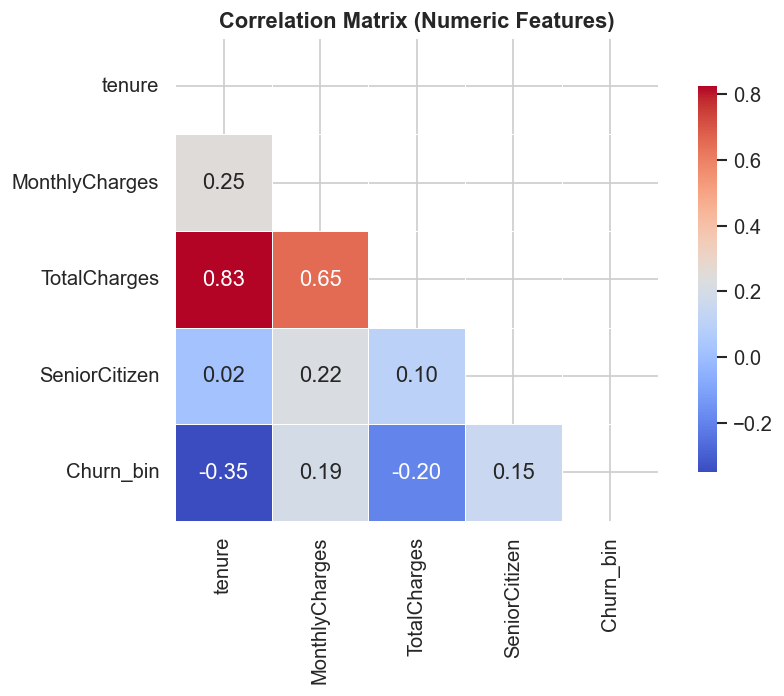


🔍 Note: tenure & TotalCharges are highly correlated — consider dropping one.


In [14]:
# Encode target for correlation
df['Churn_bin'] = (df['Churn'] == 'Yes').astype(int)
num_corr = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn_bin']].corr()

plt.figure(figsize=(8, 6))
mask = np.triu(np.ones_like(num_corr, dtype=bool))
sns.heatmap(num_corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.5, square=True,
            cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix (Numeric Features)', fontweight='bold')
plt.tight_layout()
plt.show()

print('\n🔍 Note: tenure & TotalCharges are highly correlated — consider dropping one.')

In [15]:
# Point-biserial correlation of all features with Churn
from scipy import stats

correlations = {}
for col in num_cols:
    valid = df[[col, 'Churn_bin']].dropna()
    r, p = stats.pointbiserialr(valid['Churn_bin'], valid[col])
    correlations[col] = {'correlation': round(r, 4), 'p_value': round(p, 6)}

corr_df = pd.DataFrame(correlations).T.sort_values('correlation', key=abs, ascending=False)
print('=== Feature Correlation with Churn ===')
corr_df

=== Feature Correlation with Churn ===


,correlation,p_value
tenure,-0.3522,0.0
TotalCharges,-0.1995,0.0
MonthlyCharges,0.1934,0.0


---
## 7. Bivariate Analysis (Key Feature Interactions)

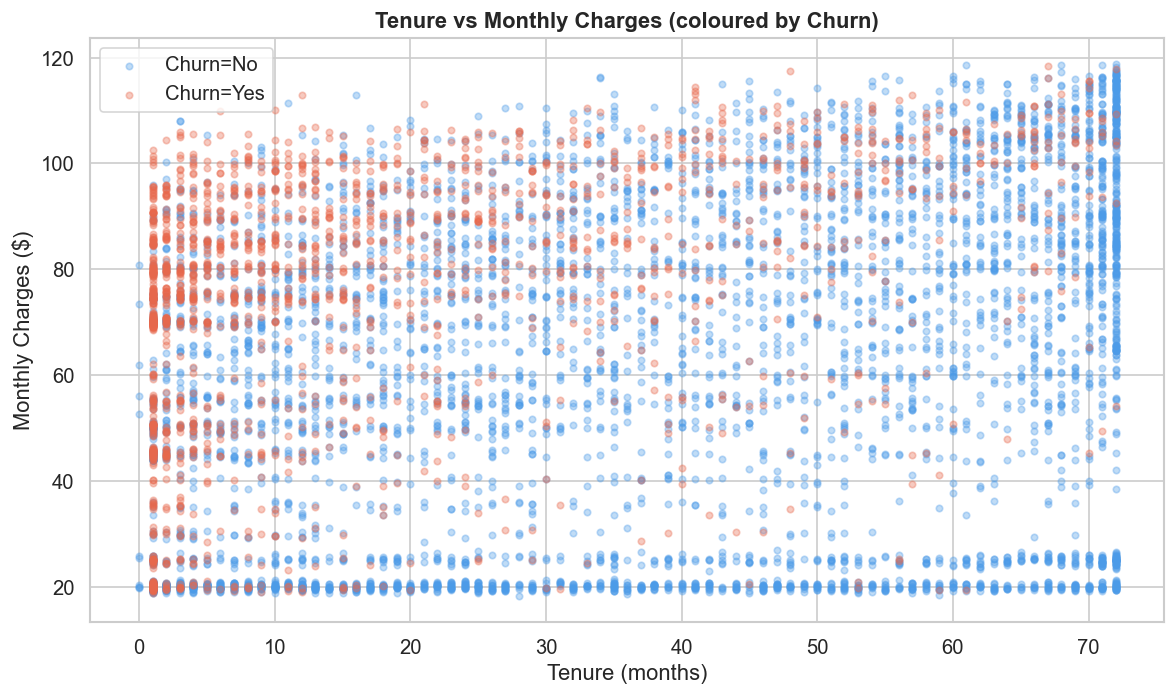

In [16]:
# Monthly charges vs Tenure, coloured by Churn
plt.figure(figsize=(10, 6))
for churn_val, color in CHURN_COLORS.items():
    subset = df[df['Churn'] == churn_val]
    plt.scatter(subset['tenure'], subset['MonthlyCharges'],
                alpha=0.35, c=color, label=f'Churn={churn_val}', s=15)
plt.xlabel('Tenure (months)')
plt.ylabel('Monthly Charges ($)')
plt.title('Tenure vs Monthly Charges (coloured by Churn)', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

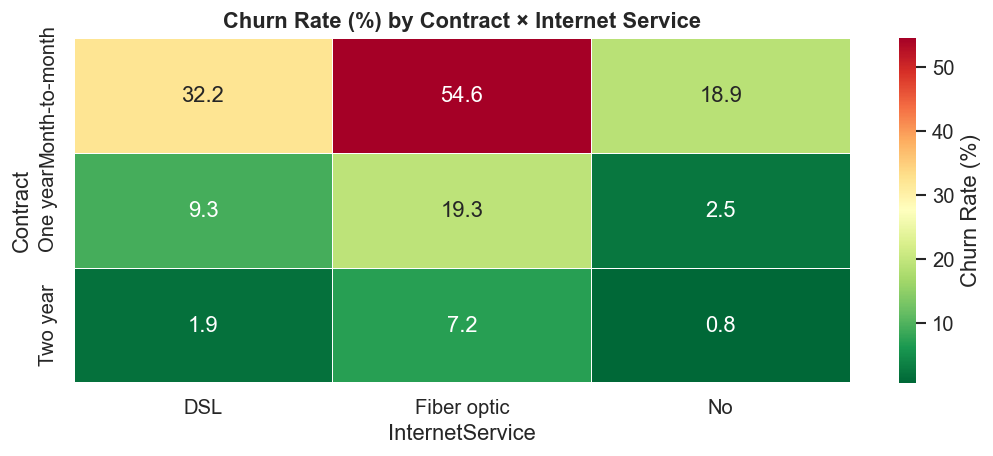

In [17]:
# Contract type × Internet service — heatmap of churn rate
pivot = df.groupby(['Contract', 'InternetService'])['Churn_bin'].mean().unstack() * 100

plt.figure(figsize=(9, 4))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn_r',
            linewidths=0.5, cbar_kws={'label': 'Churn Rate (%)'})
plt.title('Churn Rate (%) by Contract × Internet Service', fontweight='bold')
plt.tight_layout()
plt.show()

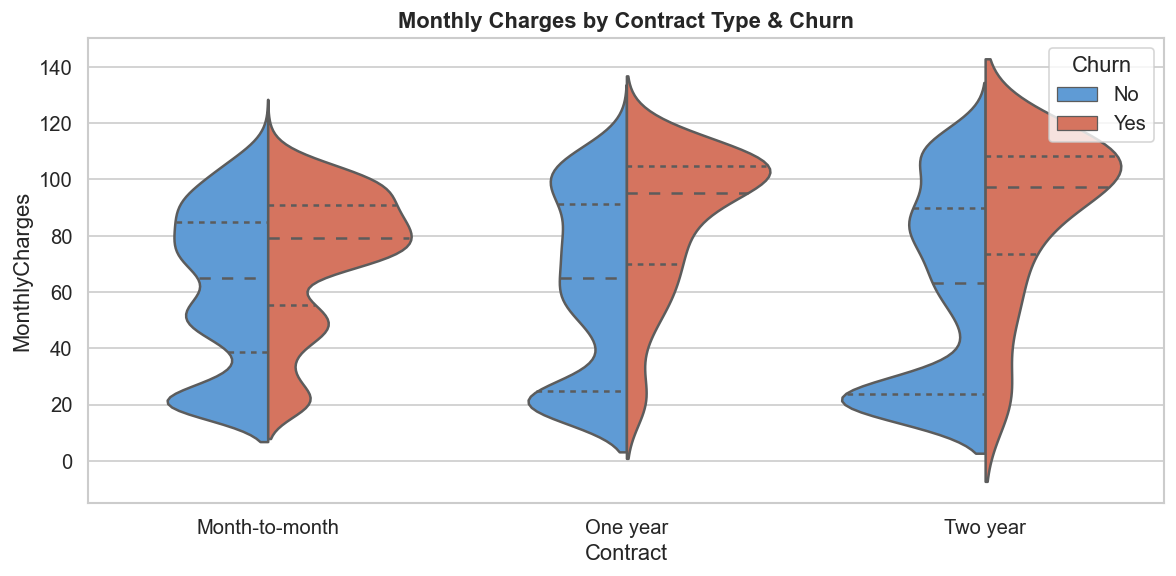

In [18]:
# Monthly charges violin plot by contract type
plt.figure(figsize=(10, 5))
sns.violinplot(data=df, x='Contract', y='MonthlyCharges', hue='Churn',
               split=True, palette=CHURN_COLORS, inner='quartile')
plt.title('Monthly Charges by Contract Type & Churn', fontweight='bold')
plt.tight_layout()
plt.show()

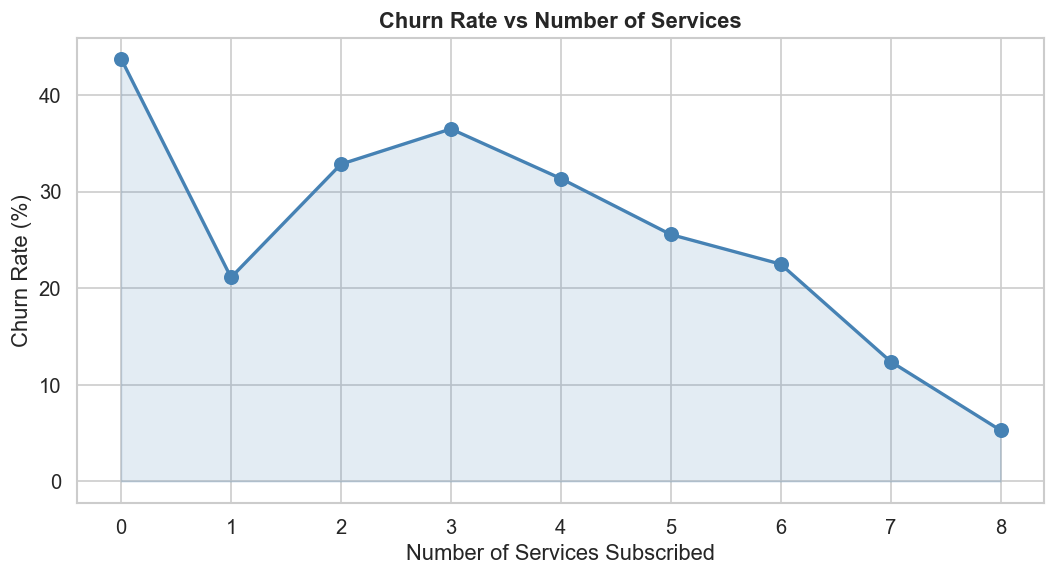

In [19]:
# Churn rate by number of services subscribed
service_cols = ['PhoneService', 'MultipleLines', 'OnlineSecurity',
                'OnlineBackup', 'DeviceProtection', 'TechSupport',
                'StreamingTV', 'StreamingMovies']

df['num_services'] = df[service_cols].apply(
    lambda row: sum(v == 'Yes' for v in row), axis=1
)

svc_churn = df.groupby('num_services')['Churn_bin'].mean() * 100

plt.figure(figsize=(9, 5))
plt.plot(svc_churn.index, svc_churn.values, marker='o', color='steelblue', linewidth=2, markersize=8)
plt.fill_between(svc_churn.index, svc_churn.values, alpha=0.15, color='steelblue')
plt.xlabel('Number of Services Subscribed')
plt.ylabel('Churn Rate (%)')
plt.title('Churn Rate vs Number of Services', fontweight='bold')
plt.xticks(svc_churn.index)
plt.tight_layout()
plt.show()

---
## 8. Key Insights & Next Steps

In [ ]:
print("""
╔══════════════════════════════════════════════════════════════════╗
║                     KEY EDA INSIGHTS                            ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  1. CLASS IMBALANCE                                              ║
║     ~26% churn rate → apply SMOTE during training.              ║
║                                                                  ║
║  2. TENURE                                                       ║
║     New customers (<12 months) churn much more than long-term.  ║
║     Strong negative correlation with churn.                     ║
║                                                                  ║
║  3. CONTRACT TYPE                                                ║
║     Month-to-month customers have highest churn rate (~43%).    ║
║     2-year contract customers rarely churn (~3%).               ║
║                                                                  ║
║  4. INTERNET SERVICE                                             ║
║     Fiber optic users churn more than DSL or no-internet.      ║
║     Possibly due to higher prices.                              ║
║                                                                  ║
║  5. MONTHLY CHARGES                                              ║
║     Churned customers pay higher monthly charges on average.    ║
║                                                                  ║
║  6. MULTICOLLINEARITY                                            ║
║     TotalCharges = tenure × MonthlyCharges (highly correlated). ║
║     Consider dropping TotalCharges or engineering a ratio.      ║
║                                                                  ║
║  7. SERVICES                                                     ║
║     More services subscribed → slightly lower churn.            ║
║     Security/support services reduce churn risk.               ║
║                                                                  ║
╠══════════════════════════════════════════════════════════════════╣
║  NEXT STEPS → 02_feature_engineering.ipynb                      ║
║  • Encode categoricals                                           ║
║  • Create interaction features (charges_per_month, etc.)        ║
║  • Handle multicollinearity                                      ║
║  • Build sklearn Pipeline                                        ║
╚══════════════════════════════════════════════════════════════════╝
""")

In [20]:
# Save a clean copy of the EDA-processed dataframe for reference
eda_summary = df.groupby('Churn')[['tenure', 'MonthlyCharges', 'TotalCharges']].agg(['mean', 'median']).round(2)
print('=== Numeric Feature Summary by Churn ===')
eda_summary

=== Numeric Feature Summary by Churn ===


tenure        MonthlyCharges        TotalCharges         
        mean median           mean median         mean   median
Churn                                                          
No     37.57   38.0          61.27  64.43      2555.34  1683.60
Yes    17.98   10.0          74.44  79.65      1531.80   703.55